In [41]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [42]:
# Define the local folder filename
csv_filename = 'eia_retail_sales_mwh_monthly_state_sectorwide.csv'
# Read the CSV file from the specified path
full_path = os.path.join(r'C:\Users\TobyWong\Desktop\School\EIA Power Prediction\EIA_end_customer_sales_power_prediction_NC\data', csv_filename)
df_raw = pd.read_csv(full_path)

print(df_raw.head())

       period stateid stateDescription          ALL         COM         IND  \
0  2025-11-01      AK           Alaska    527.61559   224.56105   121.97796   
1  2025-11-01      AL          Alabama   6491.29687  1705.24329  2608.91400   
2  2025-11-01      AR         Arkansas   3793.90892   861.62639  1782.93170   
3  2025-11-01      AZ          Arizona   6355.53426  2912.45001  1223.96740   
4  2025-11-01      CA       California  17889.55248  8947.44451  3193.78878   

   OTH         RES       TRA               salesUnit  
0  NaN   181.07658   0.00000  million kilowatt hours  
1  NaN  2177.13957   0.00000  million kilowatt hours  
2  NaN  1149.33005   0.02078  million kilowatt hours  
3  NaN  2218.25053   0.86633  million kilowatt hours  
4  NaN  5693.06000  55.25918  million kilowatt hours  


In [46]:
#SET VARIABLES FOR GRAPHING
state = 'NC'
df_graph = df_raw.copy()
df_graph = df_graph[df_graph['stateid'] == state]
print(df_graph.head())

         period stateid stateDescription          ALL         COM         IND  \
31   2025-11-01      NC   North Carolina  10171.88351  3730.97423  2042.34303   
93   2025-10-01      NC   North Carolina  10223.26233  3963.42146  2156.82230   
155  2025-09-01      NC   North Carolina  11172.62784  4200.66580  2205.06838   
217  2025-08-01      NC   North Carolina  12992.49090  4738.26372  2366.86919   
279  2025-07-01      NC   North Carolina  14736.96596  5204.65442  2396.58554   

     OTH         RES      TRA               salesUnit  
31   NaN  4397.68424  0.88200  million kilowatt hours  
93   NaN  4101.98241  1.03616  million kilowatt hours  
155  NaN  4765.80117  1.09249  million kilowatt hours  
217  NaN  5886.22161  1.13638  million kilowatt hours  
279  NaN  7134.57858  1.14742  million kilowatt hours  


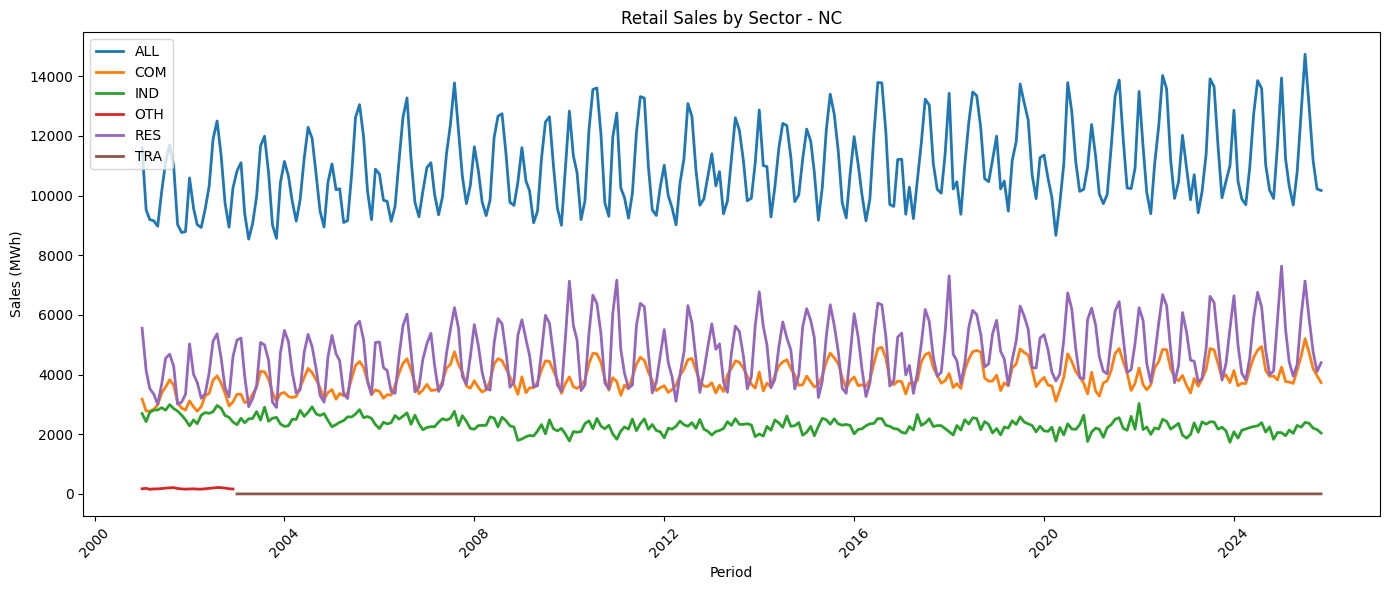

In [48]:
df_graph['period'] = pd.to_datetime(df_graph['period'])
df_graph_sorted = df_graph.sort_values('period')

plt.figure(figsize=(14, 6))
plt.plot(df_graph_sorted['period'], df_graph_sorted['ALL'], label='ALL', linewidth=2)
plt.plot(df_graph_sorted['period'], df_graph_sorted['COM'], label='COM', linewidth=2)
plt.plot(df_graph_sorted['period'], df_graph_sorted['IND'], label='IND', linewidth=2)
plt.plot(df_graph_sorted['period'], df_graph_sorted['OTH'], label='OTH', linewidth=2)
plt.plot(df_graph_sorted['period'], df_graph_sorted['RES'], label='RES', linewidth=2)
plt.plot(df_graph_sorted['period'], df_graph_sorted['TRA'], label='TRA', linewidth=2)

plt.xlabel('Period')
plt.ylabel('Sales (MWh)')
plt.title(f'Retail Sales by Sector - {state}')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [53]:
#Grouped by year
df_graph_grouped_by_year = df_graph.copy()
df_graph_grouped_by_year['year'] = df_graph_grouped_by_year['period'].dt.year
df_yearly = df_graph_grouped_by_year.groupby('year')[['ALL', 'COM', 'IND', 'OTH', 'RES', 'TRA']].sum().reset_index()    
df_yearly.head()

,year,ALL,COM,IND,OTH,RES,TRA
0,2001,119026.94299,37744.14700,32931.13900,2150.94099,46200.71601,0.000
1,2002,122686.46799,39276.81301,31381.08902,2174.14901,49854.41701,0.000
2,2003,121335.12099,41672.01798,30314.33600,0.00000,49348.76700,0.000
3,2004,125656.80699,42864.26100,31075.16601,0.00000,51717.38000,0.000
4,2005,128335.37699,44161.32800,30101.27900,0.00000,54072.73400,0.036


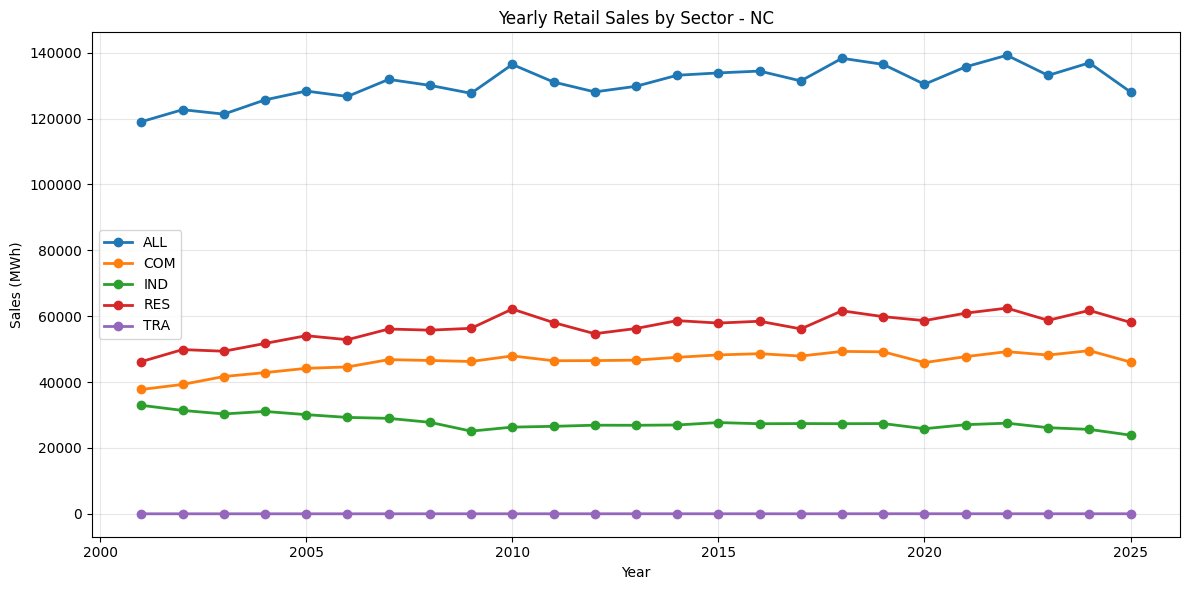

In [54]:
plt.figure(figsize=(12, 6))
plt.plot(df_yearly['year'], df_yearly['ALL'], marker='o', label='ALL', linewidth=2)
plt.plot(df_yearly['year'], df_yearly['COM'], marker='o', label='COM', linewidth=2)
plt.plot(df_yearly['year'], df_yearly['IND'], marker='o', label='IND', linewidth=2)
plt.plot(df_yearly['year'], df_yearly['RES'], marker='o', label='RES', linewidth=2)
plt.plot(df_yearly['year'], df_yearly['TRA'], marker='o', label='TRA', linewidth=2)

plt.xlabel('Year')
plt.ylabel('Sales (MWh)')
plt.title(f'Yearly Retail Sales by Sector - {state}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()